# XGBoost — Strategy B: Random Undersampling

XGBoost is trained using random undersampling to balance the training data by reducing the majority class. This approach provides a direct comparison with SMOTE oversampling by using fewer non-diabetes samples instead of generating synthetic diabetes samples. Hyperparameter tuning is performed with stratified cross-validation, and the final model is evaluated on the original imbalanced test set.

In [21]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import matplotlib.pyplot as plt
import numpy as np
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
import os

In [3]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [4]:

pipeline = Pipeline([
    ("undersampling", RandomUnderSampler(random_state=42)),
    ("model", XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5],
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC AUC:", random_search.best_score_)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best parameters: {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Best CV ROC AUC: 0.8309948731694927


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

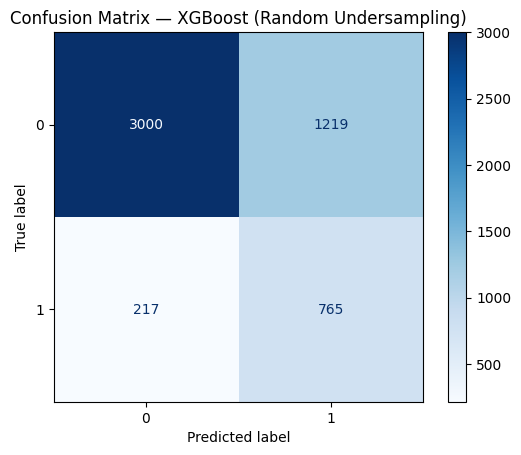

Confusion Matrix:
[[3000 1219]
 [ 217  765]]
Accuracy: 0.7239
ROC AUC: 0.8251

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81      4219
         1.0       0.39      0.78      0.52       982

    accuracy                           0.72      5201
   macro avg       0.66      0.75      0.66      5201
weighted avg       0.83      0.72      0.75      5201



In [5]:
best_model = random_search.best_estimator_

predictions = best_model.predict(X_test_final)

pred_probabilities = best_model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost (Random Undersampling)")
plt.show()

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [6]:
metrics = {

    "Strategy": "Undersampling",

    "Model": "XGBoost",

    "Accuracy": accuracy_score(y_test, predictions),

    "Precision": precision_score(y_test, predictions),

    "Recall": recall_score(y_test, predictions),

    "F1-score": f1_score(y_test, predictions),

    "ROC AUC": roc_auc_score(y_test, pred_probabilities)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/xgboost_undersampling_metrics.csv", index=False)

## Explainability with SHAP

In [34]:
import shap

 99%|===================| 5150/5201 [01:25<00:00]        /opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #11 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #13 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #14 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #16 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try in

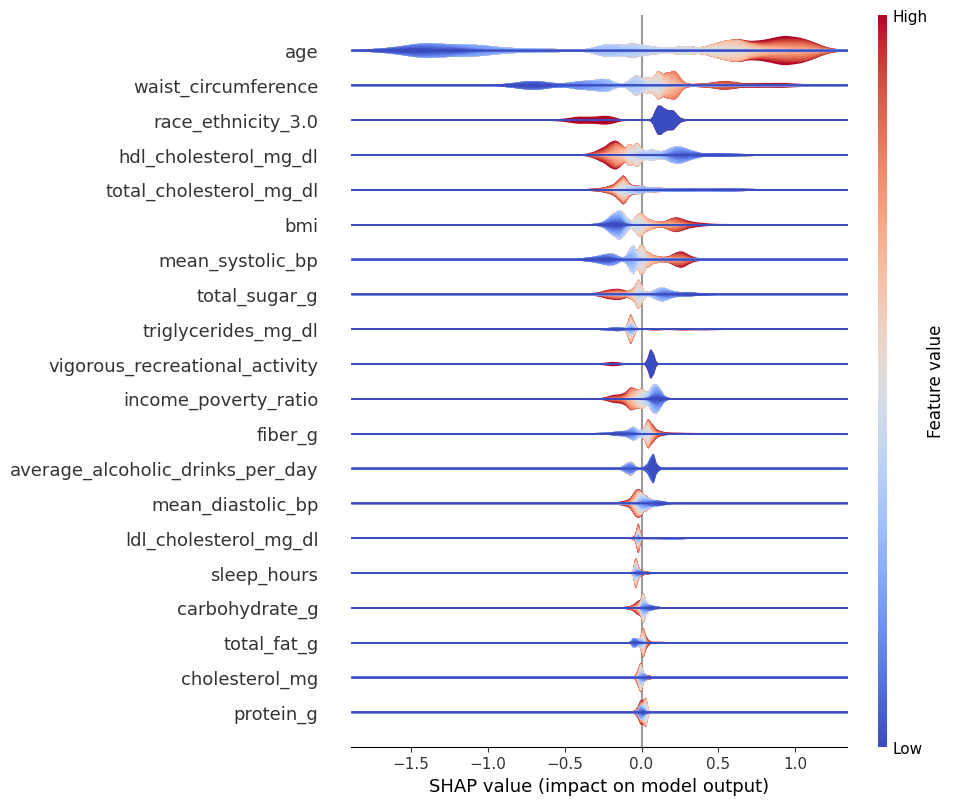

In [35]:
import numpy as np

est = best_model.named_steps["model"] 

X_train_shap = X_train_final.astype(np.float64)
X_test_shap = X_test_final.astype(np.float64)

background = X_train_shap.sample(n=min(100, len(X_train_shap)), random_state=0)

explainer = shap.TreeExplainer(est, data=background)
sv = explainer.shap_values(X_test_shap)

if isinstance(sv, list):
    sv = sv[1]

mean_abs = np.abs(sv).mean(axis=0)
feat_names = list(X_test_shap.columns)

importance_df = pd.DataFrame({"Feature": feat_names, "MeanAbsSHAP": mean_abs})

importance_df = importance_df.sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)

importance_df.head(10)

shap.plots.violin(
    sv,
    features=X_test_shap,
    feature_names=list(X_test_shap.columns),
    plot_type="layered_violin"
)



In [ ]:
importance_df = importance_df[:10]
current_strategy = "Random Undersampling"
model = "XGBoost"
output_csv_path = "../RESULTS/FEATURES/xgboost_undersampling_feature_metrics.csv"

imp_col = "MeanAbsSHAP"
method = "SHAP"

metrics = []
for rank, row in importance_df.reset_index(drop=True).iterrows():
    metrics.append({
        "Model": model,
        "Strategy": current_strategy,
        "Method": method,
        "Feature": row["Feature"],
        "Importance": float(row[imp_col]),
        "Rank": rank + 1
    })


file_exists = os.path.isfile(output_csv_path)

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(
    output_csv_path, 
    mode='a',            
    index=False, 
    header=not file_exists 
)

## Explainability with Permutation

In [37]:
from sklearn.inspection import permutation_importance

In [38]:
perm_importance = permutation_importance(
    best_model,
    X_test_final,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

,Feature,Importance Mean,Importance Std
0,age,0.141496,0.007632
3,waist_circumference,0.028216,0.003843
14,total_cholesterol_mg_dl,0.017481,0.001747
28,race_ethnicity_3.0,0.015811,0.002063
15,hdl_cholesterol_mg_dl,0.011906,0.001185
21,total_sugar_g,0.010157,0.001530
16,triglycerides_mg_dl,0.007220,0.001506
2,bmi,0.003457,0.001207
4,mean_systolic_bp,0.003319,0.001649
5,mean_diastolic_bp,0.002495,0.000818


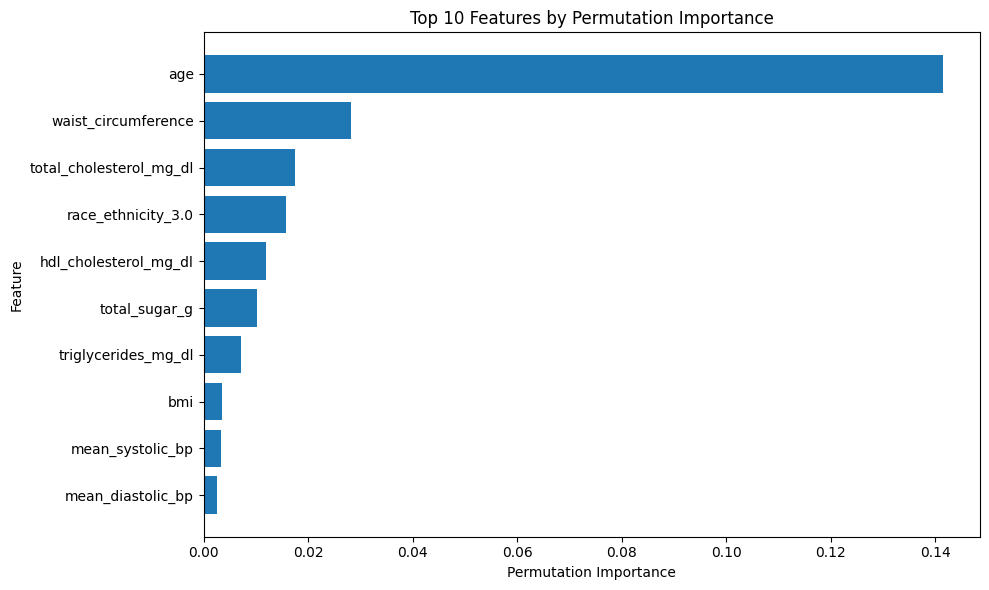

In [41]:
importance_df = pd.DataFrame({
    "Feature": X_test_final.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
)

importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
)

display(importance_df)

top_n = 10

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"][:top_n][::-1],
    importance_df["Importance Mean"][:top_n][::-1]
)
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features by Permutation Importance")
plt.tight_layout()
plt.show()


In [42]:
current_model = "XGBoost"
current_strategy = "Random Undersampling"
output_csv_path = "../RESULTS/FEATURES/xgboost_undersampling_feature_metrics.csv"

top_10_df = importance_df.head(10).copy()

imp_col = "Importance Mean"
method = "Permutation"

metrics = []

for rank, row in top_10_df.reset_index(drop=True).iterrows():
    metrics.append({
        "Model": current_model,
        "Strategy": current_strategy,
        "Method": method,
        "Feature": row["Feature"],
        "Importance": float(row[imp_col]),
        "Rank": rank + 1
    })
metrics_df = pd.DataFrame(metrics)

file_exists = os.path.isfile(output_csv_path)

metrics_df.to_csv(
    output_csv_path, 
    mode='a',            
    index=False, 
    header=not file_exists 
)

## Explainability with built-in XGBoost feature importance

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
model = best_model.named_steps["model"]

booster = model.get_booster()
importance = booster.get_score(importance_type="gain")

importance_df = pd.DataFrame(
    importance.items(),
    columns=["Feature", "Gain"]
).sort_values("Gain", ascending=False)

display(importance_df)

,Feature,Gain
0,age,45.739422
3,waist_circumference,20.376760
11,vigorous_recreational_activity,16.620989
28,race_ethnicity_3.0,15.589754
14,total_cholesterol_mg_dl,14.032690
2,bmi,12.610562
15,hdl_cholesterol_mg_dl,10.837063
16,triglycerides_mg_dl,9.323468
4,mean_systolic_bp,9.270382
21,total_sugar_g,8.597387


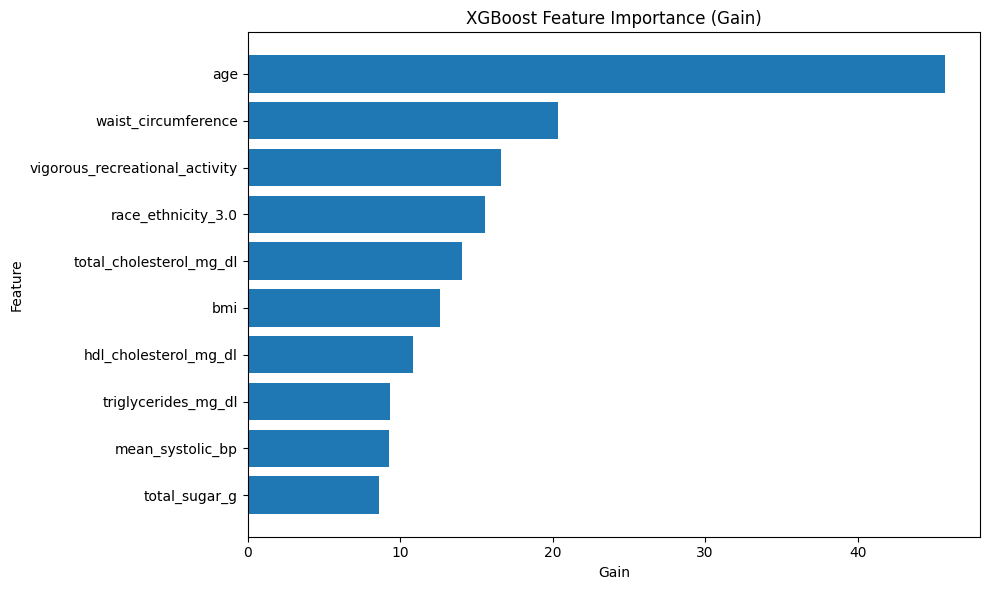

In [45]:
top_n = 10

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["Feature"][::-1],
    plot_df["Gain"][::-1]
)

plt.xlabel("Gain")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

In [46]:
current_model = "XGBoost"
current_strategy = "Random Undersampling"
output_csv_path = "../RESULTS/FEATURES/xgboost_undersampling_feature_metrics.csv"

top_10_df = importance_df.head(10).copy()

imp_col = "Gain"
method = "XGBoost Feature Importance (Gain)"

metrics = []

for rank, row in top_10_df.reset_index(drop=True).iterrows():
    metrics.append({
        "Model": current_model,
        "Strategy": current_strategy,
        "Method": method,
        "Feature": row["Feature"],
        "Importance": float(row[imp_col]),
        "Rank": rank + 1
    })
metrics_df = pd.DataFrame(metrics)

file_exists = os.path.isfile(output_csv_path)

metrics_df.to_csv(
    output_csv_path, 
    mode='a',            
    index=False, 
    header=not file_exists 
)
